# DiT-Base - Fraud Type Classification - 15K Driver's License Dataset

**Phase 2 of the forgery detection pipeline.**

Given a document already classified as FAKE by Phase 1, this model classifies the fraud type:
- **Class 0**: face_morphing
- **Class 1**: face_replacement

## Dataset
- Filtered from 15K dataset to **fakes only**
- Train: ~6,000 | Val: ~750 | Test: ~750
- Balanced ~50/50 morphing vs replacement

## Architecture

| Setting | Value |
|---------|-------|
| **Model** | DiT-Base (768-dim, 86M params) |
| **Pre-training** | IIT-CDIP (42M document images) |
| **Loss** | Focal Loss (gamma=2.0) |
| **Augmentation** | Light (preserve forgery artifacts) |
| **Training** | 3-stage gradual unfreezing |
| **Head** | MLP (LayerNorm \u2192 Linear \u2192 GELU \u2192 Dropout \u2192 Linear) |
| **TTA** | 4 augmented views |

## Setup

In [1]:
import os
import sys

project_root = "/Users/roy-siftt/final-project"
if os.path.exists(project_root):
    os.chdir(project_root)
    print(f"Working directory: {os.getcwd()}")

Working directory: /Users/roy-siftt/final-project


In [2]:
%pip install -q huggingface_hub


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from huggingface_hub import hf_hub_download
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Device
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

Using device: mps


## Load Data (Fakes Only from 15K Dataset)

In [4]:
data_dir = "notebooks/drivers_license_forgery/production/data"
dataset_root = "datasets/drivers_license_15k"

# Load full splits and filter to fakes only
fraud_type_map = {'face_morphing': 0, 'face_replacement': 1}

train_df_full = pd.read_csv(os.path.join(data_dir, "train.csv"))
val_df_full = pd.read_csv(os.path.join(data_dir, "val.csv"))
test_df_full = pd.read_csv(os.path.join(data_dir, "test.csv"))

# Filter to fakes only
train_df = train_df_full[train_df_full['is_fake'] == 1].reset_index(drop=True)
val_df = val_df_full[val_df_full['is_fake'] == 1].reset_index(drop=True)
test_df = test_df_full[test_df_full['is_fake'] == 1].reset_index(drop=True)

# Add numeric fraud type label
train_df['fraud_label'] = train_df['fraud_type'].map(fraud_type_map)
val_df['fraud_label'] = val_df['fraud_type'].map(fraud_type_map)
test_df['fraud_label'] = test_df['fraud_type'].map(fraud_type_map)

print(f"Fakes-only dataset:")
print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"  Total: {len(train_df) + len(val_df) + len(test_df)}")

print(f"\nTrain balance:")
for ft, count in train_df['fraud_type'].value_counts().items():
    print(f"  {ft}: {count} ({count/len(train_df)*100:.1f}%)")

print(f"\nVal balance:")
for ft, count in val_df['fraud_type'].value_counts().items():
    print(f"  {ft}: {count} ({count/len(val_df)*100:.1f}%)")

print(f"\nTest balance:")
for ft, count in test_df['fraud_type'].value_counts().items():
    print(f"  {ft}: {count} ({count/len(test_df)*100:.1f}%)")

Fakes-only dataset:
  Train: 6000 | Val: 750 | Test: 750
  Total: 7500

Train balance:
  face_morphing: 3010 (50.2%)
  face_replacement: 2990 (49.8%)

Val balance:
  face_morphing: 384 (51.2%)
  face_replacement: 366 (48.8%)

Test balance:
  face_replacement: 394 (52.5%)
  face_morphing: 356 (47.5%)


## Focal Loss

In [5]:
class FocalLoss(nn.Module):
    """
    Focal Loss for handling hard examples.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print("Focal Loss defined (gamma=2.0)")

Focal Loss defined (gamma=2.0)


## Lighter Augmentation Strategy

Preserve forgery artifacts, minimal blur/noise, NO CoarseDropout.

In [6]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.08,
        rotate_limit=8,
        border_mode=0,
        p=0.5
    ),
    A.Perspective(
        scale=(0.02, 0.05),
        p=0.2
    ),
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.1
    ),
    A.GaussNoise(
        std_range=(0.01, 0.03),
        p=0.1
    ),
    A.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02,
        p=0.3
    ),
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

tta_transforms = [
    val_test_transform,
    A.Compose([
        A.Resize(224, 224),
        A.Affine(scale=(0.95, 0.95), p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    A.Compose([
        A.Resize(224, 224),
        A.Affine(scale=(1.05, 1.05), p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    A.Compose([
        A.Resize(224, 224),
        A.ColorJitter(brightness=0.1, contrast=0, saturation=0, hue=0, p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
]

print("Augmentation strategy:")
print("  - LIGHTER transforms to preserve forgery artifacts")
print("  - NO CoarseDropout")
print("  - Minimal blur/noise")
print("  - TTA: 4 augmented views")

Augmentation strategy:
  - LIGHTER transforms to preserve forgery artifacts
  - NO CoarseDropout
  - Minimal blur/noise
  - TTA: 4 augmented views


## Dataset Class

In [7]:
class FraudTypeDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row['image_path'])
        img = Image.open(img_path).convert("RGB")
        img_np = np.array(img)
        
        if self.transform is not None:
            transformed = self.transform(image=img_np)
            img = transformed['image']

        label = int(row['fraud_label'])  # 0=morphing, 1=replacement
        return img, torch.tensor(label, dtype=torch.long)

# Create datasets
train_dataset = FraudTypeDataset(train_df, dataset_root, train_transform)
val_dataset = FraudTypeDataset(val_df, dataset_root, val_test_transform)
test_dataset = FraudTypeDataset(test_df, dataset_root, val_test_transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Batch size: 32")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Batch size: 32
Train batches: 187 | Val batches: 24 | Test batches: 24


## DiT-Base Model with MLP Head

In [8]:
class DiTFraudTypeClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.1):
        super(DiTFraudTypeClassifier, self).__init__()
        
        # Use timm ViT-Base with layer scale (same architecture as DiT-Base)
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0, init_values=1e-5)
        self._load_dit_weights()
        num_features = 768
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Linear(num_features, num_features // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(num_features // 2, num_classes)
        )
        
        print(f"Model: DiT-Base (microsoft/dit-base) via timm")
        print(f"  - Pre-training: IIT-CDIP (42M document images)")
        print(f"  - Hidden size: {num_features}")
        print(f"  - MLP head: {num_features} -> {num_features//2} -> {num_classes}")
        print(f"  - Classes: 0=face_morphing, 1=face_replacement")
        print(f"  - Dropout: {dropout}")
        print(f"  - Total params: {sum(p.numel() for p in self.parameters()):,}")
    
    def _load_dit_weights(self):
        weights_path = hf_hub_download(repo_id='microsoft/dit-base', filename='pytorch_model.bin')
        dit_state = torch.load(weights_path, map_location='cpu', weights_only=True)
        converted = self._convert_dit_to_timm(dit_state)
        self.backbone.load_state_dict(converted, strict=True)
        print(f"  - DiT weights loaded: {len(converted)} keys matched")
    
    @staticmethod
    def _convert_dit_to_timm(dit_state_dict):
        """Convert HuggingFace DiT/BEiT state dict to timm ViT format."""
        new_state = {}
        for key, value in dit_state_dict.items():
            k = key.replace('beit.', '') if key.startswith('beit.') else key
            if k in ('embeddings.mask_token',): continue
            if k.startswith('layernorm.'):
                new_state[k.replace('layernorm.', 'norm.')] = value; continue
            if k.startswith('classifier.') or k.startswith('lm_head.'): continue
            if k == 'embeddings.cls_token':
                new_state['cls_token'] = value; continue
            if k == 'embeddings.position_embeddings':
                new_state['pos_embed'] = value; continue
            if k.startswith('embeddings.patch_embeddings.projection.'):
                new_state[k.replace('embeddings.patch_embeddings.projection.', 'patch_embed.proj.')] = value; continue
            if k.startswith('encoder.layer.'):
                rest = k[len('encoder.layer.'):]
                layer_idx = rest.split('.')[0]
                layer_rest = rest[len(layer_idx) + 1:]
                prefix = f'blocks.{layer_idx}'
                if layer_rest == 'attention.attention.query.weight':
                    new_state[f'{prefix}.attn.q.weight'] = value; continue
                if layer_rest == 'attention.attention.key.weight':
                    new_state[f'{prefix}.attn.k.weight'] = value; continue
                if layer_rest == 'attention.attention.value.weight':
                    new_state[f'{prefix}.attn.v.weight'] = value; continue
                if layer_rest == 'attention.attention.query.bias':
                    new_state[f'{prefix}.attn.q.bias'] = value; continue
                if layer_rest == 'attention.attention.value.bias':
                    new_state[f'{prefix}.attn.v.bias'] = value; continue
                if layer_rest.startswith('attention.output.dense.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.attn.proj.{suffix}'] = value; continue
                if layer_rest.startswith('intermediate.dense.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.mlp.fc1.{suffix}'] = value; continue
                if layer_rest.startswith('output.dense.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.mlp.fc2.{suffix}'] = value; continue
                if layer_rest.startswith('layernorm_before.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.norm1.{suffix}'] = value; continue
                if layer_rest.startswith('layernorm_after.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.norm2.{suffix}'] = value; continue
                if layer_rest == 'lambda_1':
                    new_state[f'{prefix}.ls1.gamma'] = value; continue
                if layer_rest == 'lambda_2':
                    new_state[f'{prefix}.ls2.gamma'] = value; continue

        # Fuse Q, K, V weights and biases
        import torch
        fused_state = {}
        q_weight_keys = sorted([k for k in new_state if '.attn.q.weight' in k])
        for q_key in q_weight_keys:
            bp = q_key.replace('.attn.q.weight', '')
            q_w = new_state[f'{bp}.attn.q.weight']
            k_w = new_state[f'{bp}.attn.k.weight']
            v_w = new_state[f'{bp}.attn.v.weight']
            fused_state[f'{bp}.attn.qkv.weight'] = torch.cat([q_w, k_w, v_w], dim=0)
            q_b = new_state[f'{bp}.attn.q.bias']
            v_b = new_state[f'{bp}.attn.v.bias']
            k_b = torch.zeros_like(q_b)
            fused_state[f'{bp}.attn.qkv.bias'] = torch.cat([q_b, k_b, v_b], dim=0)

        skip = ('.attn.q.weight', '.attn.k.weight', '.attn.v.weight', '.attn.q.bias', '.attn.v.bias')
        for k, v in new_state.items():
            if not any(k.endswith(s) for s in skip):
                fused_state[k] = v
        return fused_state
        
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)
    
    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.classifier.parameters():
            param.requires_grad = True
        print("Backbone FROZEN")
    
    def unfreeze_backbone(self):
        for param in self.parameters():
            param.requires_grad = True
        print("Backbone UNFROZEN")
    
    def unfreeze_last_n_blocks(self, n=4):
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.classifier.parameters():
            param.requires_grad = True
        for block in self.backbone.blocks[-n:]:
            for param in block.parameters():
                param.requires_grad = True
        for param in self.backbone.norm.parameters():
            param.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f"Last {n} transformer blocks UNFROZEN ({trainable:,}/{total:,} trainable)")

model = DiTFraudTypeClassifier(num_classes=2).to(device)

  - DiT weights loaded: 174 keys matched
Model: DiT-Base (microsoft/dit-base) via timm
  - Pre-training: IIT-CDIP (42M document images)
  - Hidden size: 768
  - MLP head: 768 -> 384 -> 2
  - Classes: 0=face_morphing, 1=face_replacement
  - Dropout: 0.1
  - Total params: 86,114,690


## Training with 3-Stage Unfreezing + OneCycleLR

1. **Stage 1 (10 epochs):** Train only classifier head
2. **Stage 2 (15 epochs):** Unfreeze last 4 transformer blocks
3. **Stage 3 (25 epochs):** Full fine-tuning with lower LR

In [9]:
criterion = FocalLoss(alpha=1.0, gamma=2.0)

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
best_model_state = None
best_epoch = 0
max_grad_norm = 1.0

def evaluate(loader, use_tta=False):
    model.eval()
    
    if not use_tta:
        total, correct = 0, 0
        loss_total = 0.0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                loss_total += loss.item()
                
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        return {
            'acc': correct / total,
            'loss': loss_total / len(loader),
            'preds': all_preds,
            'labels': all_labels
        }
    else:
        all_probs = []
        all_labels = []
        
        with torch.no_grad():
            for imgs, labels in loader:
                batch_probs = []
                imgs_np = imgs.numpy().transpose(0, 2, 3, 1)
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                imgs_np = (imgs_np * std + mean) * 255
                imgs_np = imgs_np.astype(np.uint8)
                
                for tta_transform in tta_transforms:
                    tta_imgs = []
                    for img in imgs_np:
                        transformed = tta_transform(image=img)
                        tta_imgs.append(transformed['image'])
                    tta_batch = torch.stack(tta_imgs).to(device)
                    outputs = model(tta_batch)
                    probs = F.softmax(outputs, dim=1)
                    batch_probs.append(probs.cpu())
                
                avg_probs = torch.stack(batch_probs).mean(dim=0)
                all_probs.append(avg_probs)
                all_labels.extend(labels.numpy())
        
        all_probs = torch.cat(all_probs, dim=0)
        all_preds = all_probs.argmax(dim=1).numpy()
        all_labels = np.array(all_labels)
        
        correct = (all_preds == all_labels).sum()
        total = len(all_labels)
        
        return {
            'acc': correct / total,
            'loss': 0.0,
            'preds': all_preds.tolist(),
            'labels': all_labels.tolist()
        }

def train_one_epoch(train_loader, optimizer, scheduler, epoch_desc):
    model.train()
    total_loss = 0.0
    
    pbar = tqdm(train_loader, desc=epoch_desc)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})
    
    return total_loss / len(train_loader)

print("Training functions defined")
print(f"  - Focal Loss (gamma=2.0)")
print(f"  - Gradient clipping: {max_grad_norm}")
print(f"  - TTA evaluation available")

Training functions defined
  - Focal Loss (gamma=2.0)
  - Gradient clipping: 1.0
  - TTA evaluation available


In [10]:
# ============================================
# STAGE 1: Train Classifier Head Only
# ============================================
print("\n" + "="*70)
print("STAGE 1: Training Classifier Head (10 epochs, lr=5e-4)")
print("="*70)

model.freeze_backbone()

stage1_epochs = 10
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-4, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer, 
    max_lr=5e-4,
    epochs=stage1_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

for epoch in range(stage1_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S1 Epoch {epoch+1}/{stage1_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc:
        best_val_acc = val_metrics['acc']
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  -> New best: {best_val_acc:.4f}")

stage1_end = len(history['train_loss'])
print(f"\nStage 1 complete. Best val acc: {best_val_acc:.4f}")


STAGE 1: Training Classifier Head (10 epochs, lr=5e-4)
Backbone FROZEN


S1 Epoch 1/10: 100%|██████████| 187/187 [02:21<00:00,  1.32it/s, loss=0.1813, lr=5.00e-04]


  Train Acc: 0.4988 | Val Acc: 0.4880 | Val Loss: 0.1739
  -> New best: 0.4880


S1 Epoch 2/10: 100%|██████████| 187/187 [02:22<00:00,  1.31it/s, loss=0.1707, lr=4.85e-04]


  Train Acc: 0.5015 | Val Acc: 0.5120 | Val Loss: 0.1749
  -> New best: 0.5120


...

  Train Acc: 0.5201 | Val Acc: 0.5720 | Val Loss: 0.1732
  -> New best: 0.5720


S1 Epoch 9/10: 100%|██████████| 187/187 [02:24<00:00,  1.29it/s, loss=0.1748, lr=1.49e-05]


  Train Acc: 0.5363 | Val Acc: 0.5853 | Val Loss: 0.1732
  -> New best: 0.5853


S1 Epoch 10/10: 100%|██████████| 187/187 [02:24<00:00,  1.29it/s, loss=0.1748, lr=2.44e-09]


  Train Acc: 0.5281 | Val Acc: 0.5827 | Val Loss: 0.1732

Stage 1 complete. Best val acc: 0.5853


In [11]:
# ============================================
# STAGE 2: Unfreeze Last 4 Transformer Blocks
# ============================================
print("\n" + "="*70)
print("STAGE 2: Unfreezing Last 4 Blocks (15 epochs, lr=3e-5)")
print("="*70)

model.unfreeze_last_n_blocks(n=4)

stage2_epochs = 15
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-5, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer,
    max_lr=3e-5,
    epochs=stage2_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

for epoch in range(stage2_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S2 Epoch {epoch+1}/{stage2_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    total_epoch = stage1_end + epoch + 1
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc:
        best_val_acc = val_metrics['acc']
        best_epoch = total_epoch
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  -> New best: {best_val_acc:.4f}")

stage2_end = len(history['train_loss'])
print(f"\nStage 2 complete. Best val acc: {best_val_acc:.4f}")


STAGE 2: Unfreezing Last 4 Blocks (15 epochs, lr=3e-5)
Last 4 transformer blocks UNFROZEN (28,656,770/86,114,690 trainable)


S2 Epoch 1/15: 100%|██████████| 187/187 [02:51<00:00,  1.09it/s, loss=0.1665, lr=2.29e-05]


  Train Acc: 0.5533 | Val Acc: 0.5933 | Val Loss: 0.1643
  -> New best: 0.5933


S2 Epoch 2/15: 100%|██████████| 187/187 [02:53<00:00,  1.08it/s, loss=0.1313, lr=2.99e-05]


  Train Acc: 0.7059 | Val Acc: 0.7560 | Val Loss: 0.1325
  -> New best: 0.7560


...

  Train Acc: 0.8585 | Val Acc: 0.9000 | Val Loss: 0.0579


S2 Epoch 14/15: 100%|██████████| 187/187 [02:48<00:00,  1.11it/s, loss=0.0870, lr=4.00e-07]


  Train Acc: 0.8623 | Val Acc: 0.9027 | Val Loss: 0.0564


S2 Epoch 15/15: 100%|██████████| 187/187 [02:48<00:00,  1.11it/s, loss=0.0930, lr=1.32e-10]


  Train Acc: 0.8566 | Val Acc: 0.9027 | Val Loss: 0.0564

Stage 2 complete. Best val acc: 0.9080


In [12]:
# ============================================
# STAGE 3: Full Fine-Tuning
# ============================================
print("\n" + "="*70)
print("STAGE 3: Full Fine-Tuning (25 epochs, lr=5e-6)")
print("="*70)

model.unfreeze_backbone()

stage3_epochs = 25
optimizer = AdamW(model.parameters(), lr=5e-6, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer,
    max_lr=5e-6,
    epochs=stage3_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.05,
    anneal_strategy='cos'
)

patience = 8
patience_counter = 0

for epoch in range(stage3_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S3 Epoch {epoch+1}/{stage3_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    total_epoch = stage2_end + epoch + 1
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc + 0.002:
        best_val_acc = val_metrics['acc']
        best_epoch = total_epoch
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  -> New best: {best_val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {total_epoch}")
            break

print(f"\nStage 3 complete. Best val acc: {best_val_acc:.4f} at epoch {best_epoch}")


STAGE 3: Full Fine-Tuning (25 epochs, lr=5e-6)
Backbone UNFROZEN


S3 Epoch 1/25: 100%|██████████| 187/187 [03:53<00:00,  1.25s/it, loss=0.0799, lr=4.56e-06]


  Train Acc: 0.8608 | Val Acc: 0.9067 | Val Loss: 0.0566


S3 Epoch 2/25: 100%|██████████| 187/187 [03:49<00:00,  1.23s/it, loss=0.0593, lr=4.99e-06]


  Train Acc: 0.8630 | Val Acc: 0.9213 | Val Loss: 0.0524
  -> New best: 0.9213


...

  Train Acc: 0.9246 | Val Acc: 0.9467 | Val Loss: 0.0433


S3 Epoch 22/25: 100%|██████████| 187/187 [03:56<00:00,  1.26s/it, loss=0.1037, lr=1.94e-07]


  Train Acc: 0.9223 | Val Acc: 0.9467 | Val Loss: 0.0429


S3 Epoch 23/25: 100%|██████████| 187/187 [03:54<00:00,  1.25s/it, loss=0.0523, lr=8.65e-08]


  Train Acc: 0.9126 | Val Acc: 0.9467 | Val Loss: 0.0431
  Early stopping at epoch 48

Stage 3 complete. Best val acc: 0.9547 at epoch 40


In [13]:
# Load best model
print("\n" + "="*70)
print("Loading Best Model")
print("="*70)

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model from epoch {best_epoch}")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
else:
    print("Warning: No best model state saved")


Loading Best Model
Loaded best model from epoch 40
Best validation accuracy: 0.9547


## Final Evaluation

In [14]:
print("\n" + "="*70)
print("FINAL TEST EVALUATION - FRAUD TYPE (DiT-Base)")
print("="*70)

test_metrics = evaluate(test_loader, use_tta=False)
print(f"\nTest Accuracy (standard): {test_metrics['acc']:.4f}")

print("\nRunning Test-Time Augmentation (4 views)...")
test_metrics_tta = evaluate(test_loader, use_tta=True)
print(f"Test Accuracy (with TTA): {test_metrics_tta['acc']:.4f}")

labels = ['Face Morphing', 'Face Replacement']
print(f"\nClassification Report (standard):")
print(classification_report(test_metrics['labels'], test_metrics['preds'], target_names=labels))

print(f"Classification Report (TTA):")
print(classification_report(test_metrics_tta['labels'], test_metrics_tta['preds'], target_names=labels))


FINAL TEST EVALUATION - FRAUD TYPE (DiT-Base)

Test Accuracy (standard): 0.9440

Running Test-Time Augmentation (4 views)...
Test Accuracy (with TTA): 0.9373

Classification Report (standard):
                  precision    recall  f1-score   support

   Face Morphing       0.92      0.96      0.94       356
Face Replacement       0.97      0.93      0.95       394

        accuracy                           0.94       750
       macro avg       0.94      0.94      0.94       750
    weighted avg       0.94      0.94      0.94       750

Classification Report (TTA):
                  precision    recall  f1-score   support

   Face Morphing       0.91      0.96      0.94       356
Face Replacement       0.96      0.92      0.94       394

        accuracy                           0.94       750
       macro avg       0.94      0.94      0.94       750
    weighted avg       0.94      0.94      0.94       750



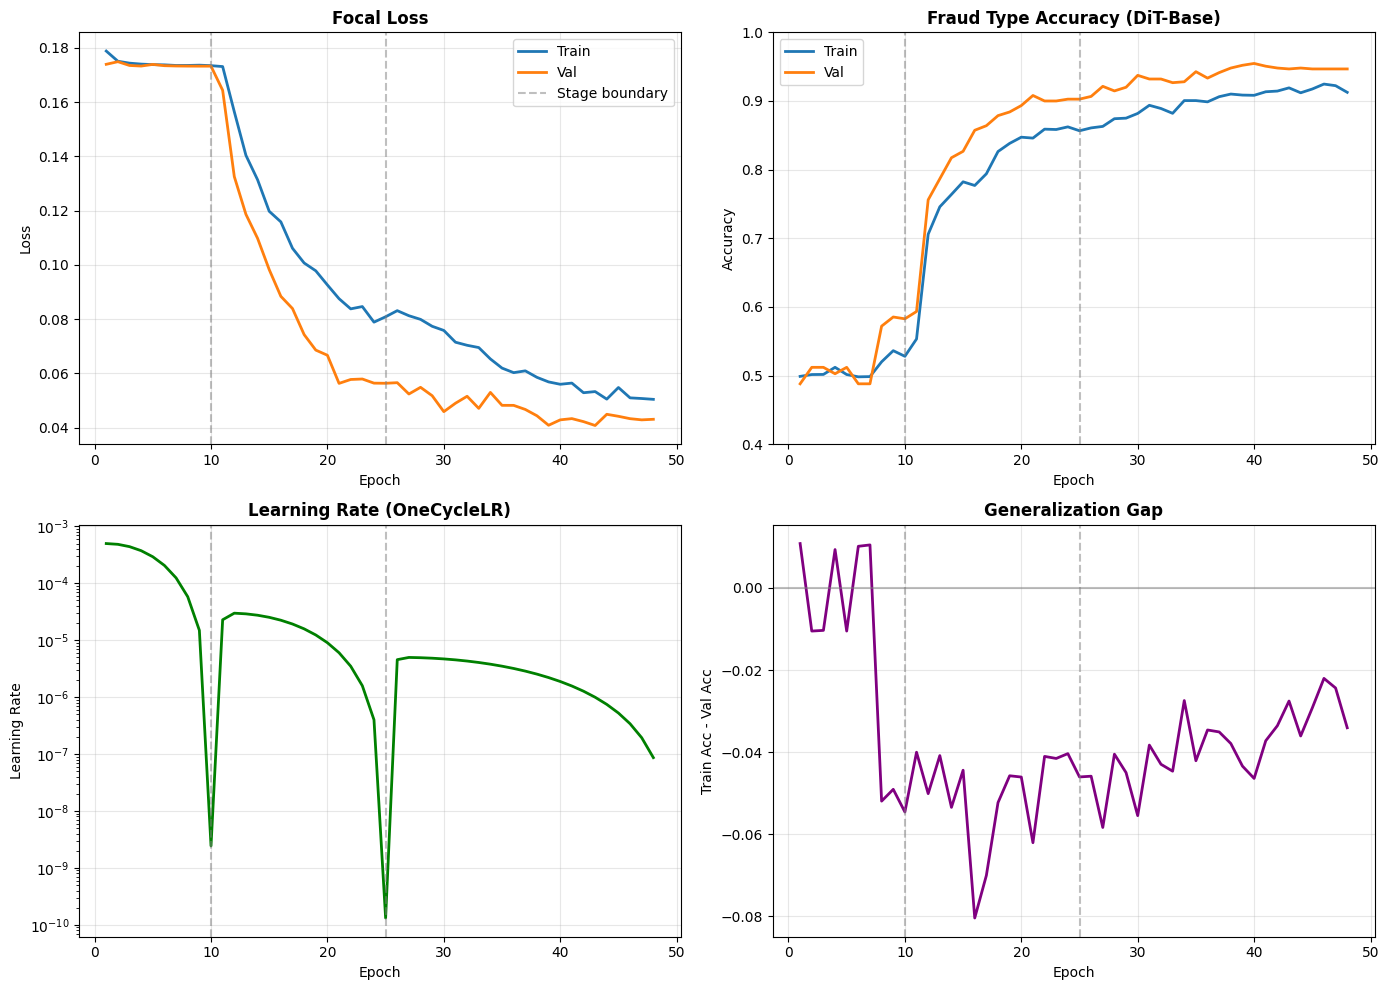

In [15]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs, history['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(epochs, history['val_loss'], label='Val', linewidth=2)
axes[0, 0].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5, label='Stage boundary')
axes[0, 0].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Focal Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs, history['train_acc'], label='Train', linewidth=2)
axes[0, 1].plot(epochs, history['val_acc'], label='Val', linewidth=2)
axes[0, 1].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Fraud Type Accuracy (DiT-Base)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.4, 1.0])

# Learning rate
axes[1, 0].plot(epochs, history['lr'], linewidth=2, color='green')
axes[1, 0].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate (OneCycleLR)', fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Generalization gap
gen_gap = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
axes[1, 1].plot(epochs, gen_gap, linewidth=2, color='purple')
axes[1, 1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[1, 1].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Train Acc - Val Acc')
axes[1, 1].set_title('Generalization Gap', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/drivers_license_forgery/production/training_curves_dit_fraud_type.png', dpi=150)
plt.show()


CONFUSION MATRIX


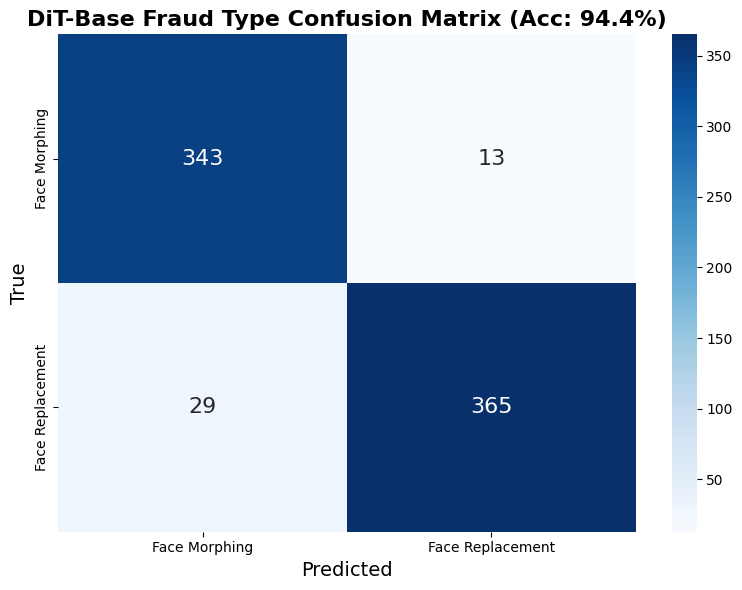


Classification Report:
                  precision    recall  f1-score   support

   Face Morphing       0.92      0.96      0.94       356
Face Replacement       0.97      0.93      0.95       394

        accuracy                           0.94       750
       macro avg       0.94      0.94      0.94       750
    weighted avg       0.94      0.94      0.94       750



In [16]:
# Confusion Matrix
print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'])
labels = ['Face Morphing', 'Face Replacement']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={'size': 16})
ax.set_xlabel('Predicted', fontsize=14)
ax.set_ylabel('True', fontsize=14)
ax.set_title(f'DiT-Base Fraud Type Confusion Matrix (Acc: {test_metrics["acc"]*100:.1f}%)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/drivers_license_forgery/production/confusion_matrix_dit_fraud_type.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(test_metrics['labels'], test_metrics['preds'], target_names=labels))

## Save Model

In [17]:
import pickle
import shutil

notebook_dir = "notebooks/drivers_license_forgery/production"
model_path = os.path.join(notebook_dir, "dit_fraud_type_15k.pth")
history_path = os.path.join(notebook_dir, "training_history_dit_fraud_type_15k.pkl")

# Check disk space
disk = shutil.disk_usage(notebook_dir)
free_gb = disk.free / (1024**3)
print(f"Disk space available: {free_gb:.1f} GB")

if free_gb < 0.5:
    print("WARNING: Low disk space! Saving to /tmp/ instead")
    model_path = "/tmp/dit_fraud_type_15k.pth"
    history_path = "/tmp/training_history_dit_fraud_type_15k.pkl"

# Save best model (move tensors to CPU first)
try:
    if best_model_state is not None:
        cpu_state = {k: v.cpu() for k, v in best_model_state.items()}
        torch.save(cpu_state, model_path)
        print(f"Model saved to: {model_path}")
        print(f"  Best epoch: {best_epoch}")
        print(f"  Best val acc: {best_val_acc:.4f}")
        print(f"  Test acc: {test_metrics['acc']:.4f}")
        print(f"  Test acc (TTA): {test_metrics_tta['acc']:.4f}")
    else:
        cpu_state = {k: v.cpu() for k, v in model.state_dict().items()}
        torch.save(cpu_state, model_path)
        print(f"Model saved to: {model_path}")
except Exception as e:
    print(f"Save failed: {e}")
    fallback = "/tmp/dit_fraud_type_15k.pth"
    cpu_state = {k: v.cpu() for k, v in (best_model_state or model.state_dict()).items()}
    torch.save(cpu_state, fallback)
    print(f"Saved to fallback: {fallback}")

# Save training history
with open(history_path, 'wb') as f:
    pickle.dump(history, f)
print(f"Training history saved to: {history_path}")

# Verify file size
if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"Model file size: {size_mb:.1f} MB")

Disk space available: 4.2 GB
Model saved to: notebooks/drivers_license_forgery/production/dit_fraud_type_15k.pth
  Best epoch: 40
  Best val acc: 0.9547
  Test acc: 0.9440
  Test acc (TTA): 0.9373
Training history saved to: notebooks/drivers_license_forgery/production/training_history_dit_fraud_type_15k.pkl
Model file size: 328.6 MB


## Out-of-Dataset Evaluation (test_samples.json -- fakes only)

In [18]:
import json

# Auto-reload transforms if needed
if 'tta_transforms' not in dir():
    print("Reloading transforms...")
    tta_transforms = [
        A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.Affine(scale=(0.95, 0.95), p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.Affine(scale=(1.05, 1.05), p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.ColorJitter(brightness=0.1, contrast=0, saturation=0, hue=0, p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
    ]

fraud_type_map_eval = {'face_morphing': 0, 'face_replacement': 1}
fraud_type_names = {0: 'Face Morphing', 1: 'Face Replacement'}

def predict_single(image_path, model, device):
    """Predict on a single image with TTA."""
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    
    model.eval()
    all_probs = []
    
    with torch.no_grad():
        for transform in tta_transforms:
            transformed = transform(image=img_np)
            img_tensor = transformed['image'].unsqueeze(0).to(device)
            outputs = model(img_tensor)
            probs = F.softmax(outputs, dim=1)
            all_probs.append(probs.cpu())
    
    avg_probs = torch.stack(all_probs).mean(dim=0)
    pred = avg_probs.argmax(dim=1).item()
    confidence = avg_probs[0][pred].item()
    
    return pred, confidence

# Load test samples and filter to fakes only
samples_path = os.path.join(project_root, "notebooks/drivers_license_forgery/experiments/test_samples.json")
with open(samples_path) as f:
    all_samples = json.load(f)

# Only evaluate on fake samples
samples = [s for s in all_samples if s['is_fake'] == 1]

print(f"\n{'='*70}")
print(f"OUT-OF-DATASET FRAUD TYPE EVALUATION ({len(samples)} fake samples)")
print(f"{'='*70}")
print(f"  face_morphing: {sum(1 for s in samples if s['fraud_type'] == 'face_morphing')}")
print(f"  face_replacement: {sum(1 for s in samples if s['fraud_type'] == 'face_replacement')}")

true_labels, pred_labels, details = [], [], []
skipped = 0

for s in tqdm(samples, desc="Evaluating"):
    img_path = os.path.join(project_root, s['path'])
    if not os.path.exists(img_path):
        skipped += 1
        continue

    true_idx = fraud_type_map_eval[s['fraud_type']]
    pred_idx, confidence = predict_single(img_path, model, device)
    
    pred_name = fraud_type_names[pred_idx]
    true_name = fraud_type_names[true_idx]

    true_labels.append(true_idx)
    pred_labels.append(pred_idx)
    details.append({
        'path': s['path'],
        'country': s['country'],
        'fraud_type': s['fraud_type'],
        'true': true_name,
        'pred': pred_name,
        'confidence': confidence,
        'correct': pred_idx == true_idx
    })

if skipped:
    print(f"Skipped {skipped} (file not found)")

# Results
correct = sum(d['correct'] for d in details)
total = len(details)
ood_accuracy = correct / total

print(f"\nOverall Accuracy: {ood_accuracy:.4f} ({correct}/{total})")

# Per fraud type
print(f"\nPer Fraud Type:")
for ftype in ['face_morphing', 'face_replacement']:
    subset = [d for d in details if d['fraud_type'] == ftype]
    acc = sum(d['correct'] for d in subset) / len(subset)
    avg_conf = sum(d['confidence'] for d in subset) / len(subset)
    print(f"  {ftype:20s}: {acc:.4f} ({sum(d['correct'] for d in subset)}/{len(subset)}) avg conf: {avg_conf:.4f}")

# Per country
print(f"\nPer Country:")
for country in ['DC', 'AZ', 'WV']:
    subset = [d for d in details if d['country'] == country]
    if len(subset) > 0:
        acc = sum(d['correct'] for d in subset) / len(subset)
        print(f"  {country}: {acc:.4f} ({sum(d['correct'] for d in subset)}/{len(subset)})")

# Classification report
print(f"\n{'='*60}")
print(classification_report(true_labels, pred_labels, target_names=['Face Morphing', 'Face Replacement']))

# Worst mistakes
wrong = sorted([d for d in details if not d['correct']], key=lambda x: -x['confidence'])
if wrong:
    print(f"\nTop 10 most confident WRONG predictions:")
    print("-" * 80)
    for d in wrong[:10]:
        fname = d['path'].split('/')[-1]
        print(f"  {d['country']} | true={d['true']:20s} pred={d['pred']:20s} | conf={d['confidence']*100:.1f}% | {fname}")


OUT-OF-DATASET FRAUD TYPE EVALUATION (666 fake samples)
  face_morphing: 333
  face_replacement: 333


Evaluating: 100%|██████████| 666/666 [00:45<00:00, 14.75it/s]


Overall Accuracy: 0.9459 (630/666)

Per Fraud Type:
  face_morphing       : 0.9459 (315/333) avg conf: 0.7713
  face_replacement    : 0.9459 (315/333) avg conf: 0.8082

Per Country:
  DC: 0.9324 (207/222)
  AZ: 0.9550 (212/222)
  WV: 0.9505 (211/222)

                  precision    recall  f1-score   support

   Face Morphing       0.95      0.95      0.95       333
Face Replacement       0.95      0.95      0.95       333

        accuracy                           0.95       666
       macro avg       0.95      0.95      0.95       666
    weighted avg       0.95      0.95      0.95       666


Top 10 most confident WRONG predictions:
--------------------------------------------------------------------------------
  AZ | true=Face Morphing        pred=Face Replacement     | conf=89.1% | generated.photos_v3_0680683_0468080_0756992.png
  WV | true=Face Replacement     pred=Face Morphing        | conf=84.9% | generated.photos_v3_0967031_0835812_0741585.png
  AZ | true=Face Morphing    

In [19]:
# Final Summary
print("\n" + "="*70)
print("FINAL SUMMARY - DiT-Base Fraud Type Classifier (Phase 2)")
print("="*70)
print(f"\nModel: DiT-Base (microsoft/dit-base) with MLP head")
print(f"Pre-training: IIT-CDIP (42M document images)")
print(f"Task: face_morphing vs face_replacement (fakes only)")
print(f"Dataset: {len(train_df)+len(val_df)+len(test_df)} fake images from 15K dataset")
print(f"Training: 3-stage unfreezing, {len(history['train_loss'])} epochs")
print(f"Loss: Focal Loss (gamma=2.0)")
print(f"\nResults:")
print(f"  Best Val Accuracy:        {best_val_acc:.4f}")
print(f"  Test Accuracy (standard): {test_metrics['acc']:.4f}")
print(f"  Test Accuracy (TTA):      {test_metrics_tta['acc']:.4f}")
print(f"  Out-of-Dataset Accuracy:  {ood_accuracy:.4f}")
print(f"\n--- Full Pipeline Summary ---")
print(f"Phase 1 (Binary):     Real vs Fake")
print(f"Phase 2 (Fraud Type): Morphing vs Replacement")
print(f"Pipeline: Image -> Phase 1 -> if Fake -> Phase 2 -> Fraud Type")


FINAL SUMMARY - DiT-Base Fraud Type Classifier (Phase 2)

Model: DiT-Base (microsoft/dit-base) with MLP head
Pre-training: IIT-CDIP (42M document images)
Task: face_morphing vs face_replacement (fakes only)
Dataset: 7500 fake images from 15K dataset
Training: 3-stage unfreezing, 48 epochs
Loss: Focal Loss (gamma=2.0)

Results:
  Best Val Accuracy:        0.9547
  Test Accuracy (standard): 0.9440
  Test Accuracy (TTA):      0.9373
  Out-of-Dataset Accuracy:  0.9459

--- Full Pipeline Summary ---
Phase 1 (Binary):     Real vs Fake
Phase 2 (Fraud Type): Morphing vs Replacement
Pipeline: Image -> Phase 1 -> if Fake -> Phase 2 -> Fraud Type
